# Time-Series Trend & Rolling Metrics Analysis

**Project:** HirePulse

This notebook analyzes offer salary value over time using resampling, rolling averages, month-over-month percentage changes, cumulative sums, and trend analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/offers.csv")
df["offer_date"] = pd.to_datetime(df["offer_date"])
df = df.sort_values("offer_date").reset_index(drop=True)

df.head()

,candidate_id,offer_date,salary,accepted
0,C0001,2025-01-26,70000,True
1,C0002,2025-01-29,74500,True
2,C0003,2025-02-01,79000,True
3,C0004,2025-02-04,83500,True
4,C0006,2025-02-05,92500,False


## 1. Prepare the Daily Time Series

Multiple offers can occur on the same date. We aggregate them by date and create a continuous daily index so missing dates are explicitly represented.

In [2]:
daily = (
    df.groupby("offer_date")
    .agg(
        offer_salary_value=("salary", "sum"),
        offer_count=("candidate_id", "count"),
        average_offer_salary=("salary", "mean")
    )
    .sort_index()
)

full_dates = pd.date_range(
    daily.index.min(),
    daily.index.max(),
    freq="D"
)

daily = daily.reindex(full_dates)
daily.index.name = "date"

daily["offer_salary_value"] = daily["offer_salary_value"].fillna(0)
daily["offer_count"] = daily["offer_count"].fillna(0)
daily["average_offer_salary"] = daily["average_offer_salary"].fillna(0)

daily.head()

,offer_salary_value,offer_count,average_offer_salary
date,,,
2025-01-26,70000.0,1.0,70000.0
2025-01-27,0.0,0.0,0.0
2025-01-28,0.0,0.0,0.0
2025-01-29,74500.0,1.0,74500.0
2025-01-30,0.0,0.0,0.0


## 2. Resampling by Time Period

Resampling aggregates data according to a datetime frequency such as week or month. Unlike a standard `groupby`, resampling is specifically designed for time-based aggregation.

In [3]:
weekly_revenue = daily["offer_salary_value"].resample("W").sum()
weekly_count = daily["offer_count"].resample("W").sum()
weekly_avg = daily["offer_salary_value"].resample("W").mean()

monthly_revenue = daily["offer_salary_value"].resample("ME").sum()
monthly_count = daily["offer_count"].resample("ME").sum()
monthly_avg = daily["offer_salary_value"].resample("ME").mean()

print("Weekly offer salary value:")
display(weekly_revenue)

print("Monthly offer salary value:")
display(monthly_revenue)

print(
    f"Highest week: {weekly_revenue.idxmax().date()} "
    f"-> ${weekly_revenue.max():,.0f}"
)

print(
    f"Highest month: {monthly_revenue.idxmax().strftime('%B %Y')} "
    f"-> ${monthly_revenue.max():,.0f}"
)

Weekly offer salary value:


date
2025-01-26     70000.0
2025-02-02    153500.0
2025-02-09    361000.0
2025-02-16     70000.0
2025-02-23    153500.0
2025-03-02    361000.0
2025-03-09     70000.0
2025-03-16    153500.0
2025-03-23    361000.0
2025-03-30     70000.0
2025-04-06    153500.0
2025-04-13    361000.0
2025-04-20     70000.0
2025-04-27    153500.0
2025-05-04    361000.0
2025-05-11     70000.0
2025-05-18    153500.0
2025-05-25    361000.0
2025-06-01     70000.0
2025-06-08    153500.0
2025-06-15    361000.0
2025-06-22     70000.0
2025-06-29    153500.0
2025-07-06    361000.0
2025-07-13     70000.0
2025-07-20    153500.0
2025-07-27    361000.0
2025-08-03     70000.0
2025-08-10    153500.0
2025-08-17    361000.0
Freq: W-SUN, Name: offer_salary_value, dtype: float64

Monthly offer salary value:


date
2025-01-31    144500.0
2025-02-28    927500.0
2025-03-31    751500.0
2025-04-30    914000.0
2025-05-31    769500.0
2025-06-30    808000.0
2025-07-31    945500.0
2025-08-31    584500.0
Freq: ME, Name: offer_salary_value, dtype: float64

Highest week: 2025-02-09 -> $361,000
Highest month: July 2025 -> $945,500


## 3. Rolling Window Averages

A rolling average calculates the mean over a moving window. The 7-day window reacts more quickly to changes, while the 30-day window smooths more noise and shows the broader trend.

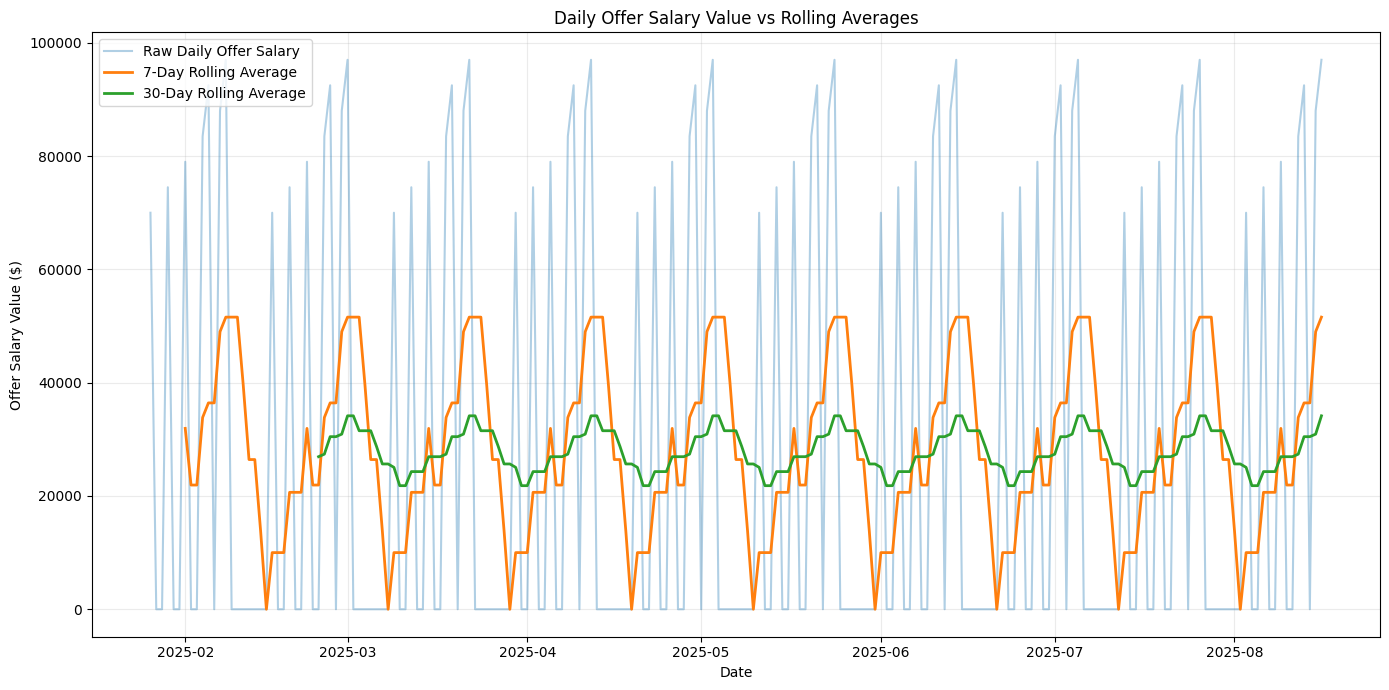

In [4]:
daily["revenue_ma7"] = (
    daily["offer_salary_value"]
    .rolling(window=7, min_periods=7)
    .mean()
)

daily["revenue_ma30"] = (
    daily["offer_salary_value"]
    .rolling(window=30, min_periods=30)
    .mean()
)

plt.figure(figsize=(14, 7))

plt.plot(
    daily.index,
    daily["offer_salary_value"],
    label="Raw Daily Offer Salary",
    alpha=0.35
)

plt.plot(
    daily.index,
    daily["revenue_ma7"],
    label="7-Day Rolling Average",
    linewidth=2
)

plt.plot(
    daily.index,
    daily["revenue_ma30"],
    label="30-Day Rolling Average",
    linewidth=2
)

plt.title("Daily Offer Salary Value vs Rolling Averages")
plt.xlabel("Date")
plt.ylabel("Offer Salary Value ($)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Month-over-Month Percentage Change

`.pct_change()` compares the current period with the previous period. Positive values indicate growth, while negative values indicate decline.

In [5]:
mom_change = monthly_revenue.pct_change() * 100

print("Month-over-month percentage change:")
display(mom_change)

print("Positive-growth months:")
display(mom_change[mom_change > 0])

print("Declining months:")
display(mom_change[mom_change < 0])

Month-over-month percentage change:


date
2025-01-31           NaN
2025-02-28    541.868512
2025-03-31    -18.975741
2025-04-30     21.623420
2025-05-31    -15.809628
2025-06-30      5.003249
2025-07-31     17.017327
2025-08-31    -38.180857
Freq: ME, Name: offer_salary_value, dtype: float64

Positive-growth months:


date
2025-02-28    541.868512
2025-04-30     21.623420
2025-06-30      5.003249
2025-07-31     17.017327
Name: offer_salary_value, dtype: float64

Declining months:


date
2025-03-31   -18.975741
2025-05-31   -15.809628
2025-08-31   -38.180857
Name: offer_salary_value, dtype: float64

## 5. Cumulative Offer Salary Value

A cumulative sum tracks the total offer salary value accumulated from the beginning of the analysis period.

Total accumulated offer salary value: $5,845,000


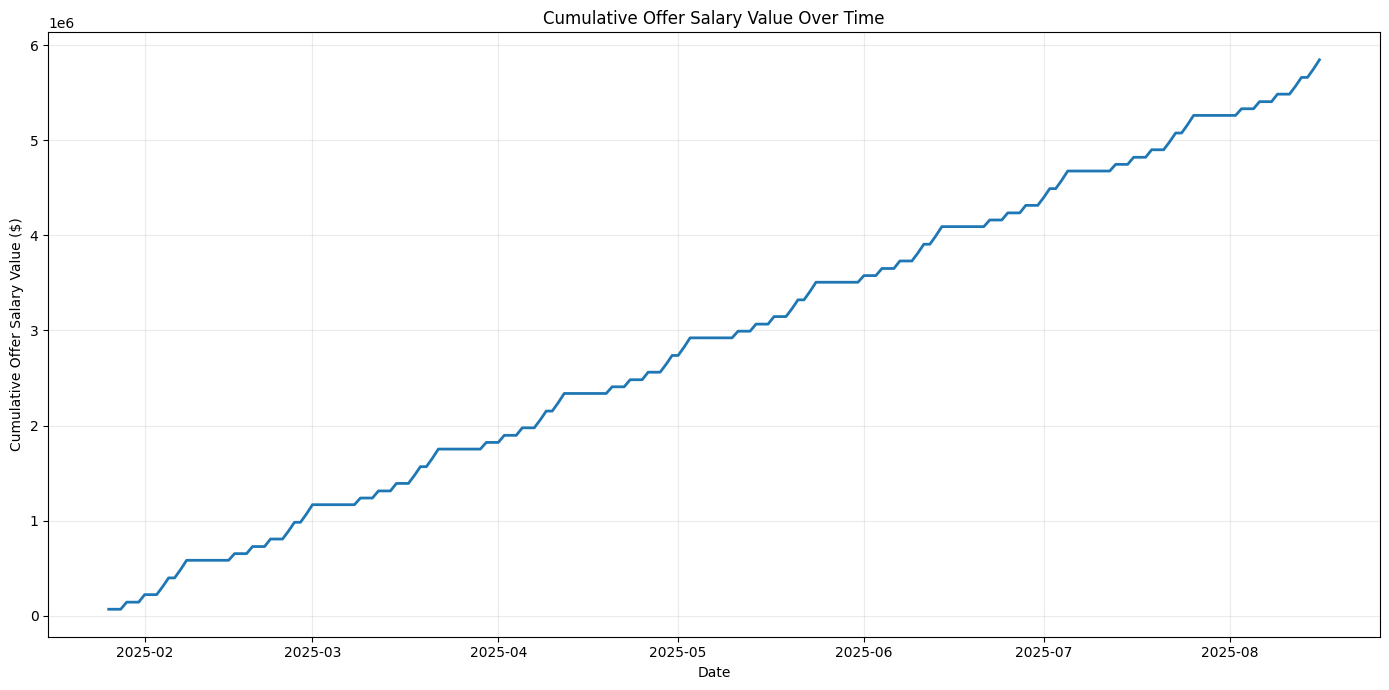

In [6]:
daily["cumulative_revenue"] = (
    daily["offer_salary_value"].cumsum()
)

total_accumulated = daily["cumulative_revenue"].iloc[-1]

print(
    f"Total accumulated offer salary value: "
    f"${total_accumulated:,.0f}"
)

plt.figure(figsize=(14, 7))

plt.plot(
    daily.index,
    daily["cumulative_revenue"],
    linewidth=2
)

plt.title("Cumulative Offer Salary Value Over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative Offer Salary Value ($)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Trend Analysis and Business Implications

The rolling average provides a smoother view of the underlying direction. We also consider the latest month-over-month result so that short-term changes are not hidden by the broader trend.

In [7]:
recent_ma30 = (
    daily["revenue_ma30"]
    .dropna()
    .tail(30)
)

first_ma = recent_ma30.iloc[0]
last_ma = recent_ma30.iloc[-1]

trend_magnitude = (
    (last_ma - first_ma) / first_ma
) * 100

if trend_magnitude > 1:
    trend_direction = "UP"
elif trend_magnitude < -1:
    trend_direction = "DOWN"
else:
    trend_direction = "FLAT"

latest_mom = mom_change.dropna().iloc[-1]
daily_volatility = daily["offer_salary_value"].std()

print(f"Rolling-average trend: {trend_direction}")
print(
    f"Change over recent 30-day rolling window: "
    f"{trend_magnitude:.2f}%"
)
print(f"Latest MoM change: {latest_mom:.2f}%")
print(f"Daily volatility: ${daily_volatility:,.2f}")

print("\nBusiness interpretation:")
print(
    "The broader recent rolling trend is upward, "
    "but the latest month shows a significant decline. "
    "This indicates positive recent momentum together "
    "with short-term volatility."
)

print("\nSuggested action:")
print(
    "Monitor the next monthly period, investigate the "
    "causes of the latest decline, and review recruiting "
    "pipeline and onboarding capacity."
)

Rolling-average trend: UP
Change over recent 30-day rolling window: 40.53%
Latest MoM change: -38.18%
Daily volatility: $40,137.87

Business interpretation:
The broader recent rolling trend is upward, but the latest month shows a significant decline. This indicates positive recent momentum together with short-term volatility.

Suggested action:
Monitor the next monthly period, investigate the causes of the latest decline, and review recruiting pipeline and onboarding capacity.


## 7. Missing Data Handling

Time-series data can contain missing calendar dates. We created a complete daily date range using `pd.date_range()` and represented dates with no offers as zero activity.

This is appropriate when a missing date genuinely means that no offers occurred. Other situations may require forward-filling, interpolation, or leaving the value missing.

## Conclusion

Raw daily data shows substantial volatility. Weekly and monthly resampling provides an aggregated business view, while 7-day and 30-day rolling averages smooth daily noise.

The HirePulse data shows a positive recent rolling trend, but the latest month has a significant decline. Both the long-term smoothed signal and the latest period change should therefore be monitored.

**Note:** HirePulse does not contain actual revenue. `offer_salary_value` is used as the business metric and represents the total salary attached to offers, not company revenue.